#Importando as bibliotecas necessárias

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

class FraudDetection:
    def __init__(self, file_path, sample_frac=0.3, random_state=42):
        self.df = pd.read_csv(file_path)
        self.df = self.df.sample(frac=sample_frac, random_state=random_state)
        self.label_encoders = {}

    def encode_categorical_columns(self):
        # Identifica as colunas categóricas
        categorical_cols = self.df.select_dtypes(include=['object']).columns

        # Aplica Label Encoding a cada coluna categórica
        for col in categorical_cols:
            le = LabelEncoder()
            self.df[col] = le.fit_transform(self.df[col].astype(str))
            self.label_encoders[col] = le

    def exploratory_analysis(self):
        # Análise estatística descritiva
        print(self.df.describe())

        # Verificação de valores ausentes
        print(self.df.isnull().sum())

        # Distribuição das classes
        sns.countplot(x='isFraud', data=self.df)
        plt.title('Distribuição de Fraudes')
        plt.show()

        # Correlações
        corr_matrix = self.df.corr()
        sns.heatmap(corr_matrix, cmap='coolwarm', vmax=0.3, annot=False, fmt=".2f")
        plt.title('Matriz de Correlação')
        plt.show()

        # Outliers em TransactionAmt
        sns.boxplot(x=self.df['TransactionAmt'])
        plt.title('Outliers em TransactionAmt')
        plt.show()

    def data_preparation(self):
        # Trata valores ausentes
        self.df.fillna(self.df.mean(), inplace=True)

        # Codifica colunas categóricas
        self.encode_categorical_columns()

        # Normalização dos valores
        scaler = StandardScaler()
        self.df['TransactionAmt'] = scaler.fit_transform(self.df['TransactionAmt'].values.reshape(-1, 1))

        # Criação de sequências temporais
        self.df.sort_values(by='TransactionDT', inplace=True)
        self.X, self.y = [], []
        seq_length = 10
        for i in range(len(self.df) - seq_length):
            self.X.append(self.df.iloc[i:i+seq_length].drop(columns=['isFraud']).values)
            self.y.append(self.df.iloc[i+seq_length]['isFraud'])
        self.X, self.y = np.array(self.X), np.array(self.y)

        # Separação em conjunto de treino e teste
        self.X_train, self.X_test, self.y_train, self.y_test = train_test_split(self.X, self.y, test_size=0.2, random_state=42)

    def build_model(self, input_shape):
        model = Sequential()
        model.add(LSTM(64, input_shape=input_shape, return_sequences=True))
        model.add(Dropout(0.2))
        model.add(LSTM(32, return_sequences=False))
        model.add(Dropout(0.2))
        model.add(Dense(1, activation='sigmoid'))

        model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
        return model

    def analyze_results(self, history, y_test, y_pred, y_pred_class):
        # Plotando a curva de aprendizado (Acurácia)
        plt.figure(figsize=(14, 6))

        plt.subplot(1, 2, 1)
        plt.plot(history.history['accuracy'], label='Train Accuracy')
        plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
        plt.xlabel('Epochs')
        plt.ylabel('Accuracy')
        plt.legend()
        plt.title('Learning Curve: Accuracy')

        # Plotando a curva de aprendizado (Perda)
        plt.subplot(1, 2, 2)
        plt.plot(history.history['loss'], label='Train Loss')
        plt.plot(history.history['val_loss'], label='Validation Loss')
        plt.xlabel('Epochs')
        plt.ylabel('Loss')
        plt.legend()
        plt.title('Learning Curve: Loss')

        plt.show()

        # Análise de overfitting ou underfitting
        train_accuracy = history.history['accuracy'][-1]
        val_accuracy = history.history['val_accuracy'][-1]
        train_loss = history.history['loss'][-1]
        val_loss = history.history['val_loss'][-1]

        print(f"Final Training Accuracy: {train_accuracy:.4f}")
        print(f"Final Validation Accuracy: {val_accuracy:.4f}")
        print(f"Final Training Loss: {train_loss:.4f}")
        print(f"Final Validation Loss: {val_loss:.4f}")

        if train_accuracy > val_accuracy and train_loss < val_loss:
            print("\nPossível overfitting detectado. Considere adicionar regularização, aumentar o dropout, ou coletar mais dados.")
        elif train_accuracy < val_accuracy:
            print("\nPossível underfitting detectado. Considere aumentar a complexidade do modelo ou treinar por mais epochs.")
        else:
            print("\nO modelo parece estar bem ajustado.")

        # Matriz de confusão
        cm = confusion_matrix(y_test, y_pred_class)

        sns.heatmap(cm, annot=True, fmt="d", cmap='Blues')
        plt.title('Confusion Matrix')
        plt.ylabel('Actual Label')
        plt.xlabel('Predicted Label')
        plt.show()

        # Avaliação detalhada das métricas
        print("\nClassification Report:")
        print(classification_report(y_test, y_pred_class))

        auc_score = roc_auc_score(y_test, y_pred)
        print(f"AUC-ROC Score: {auc_score:.4f}")

        # Discussão de melhorias
        if auc_score < 0.8:
            print("\nO modelo pode não estar performando de forma ótima. Considere:\n"
                  "1. Ajustar a taxa de aprendizado.\n"
                  "2. Testar diferentes arquiteturas de LSTM.\n"
                  "3. Aumentar a quantidade de dados de treino ou criar mais features.\n"
                  "4. Experimentar com técnicas de balanceamento de classes (se necessário).")
        else:
            print("\nO modelo apresentou uma boa performance. Avalie as opções para otimizar ainda mais.")

    def train_model(self):
        # Construindo e treinando o modelo
        model = self.build_model((self.X_train.shape[1], self.X_train.shape[2]))
        history = model.fit(self.X_train, self.y_train, epochs=10, batch_size=32, validation_split=0.2)

        # Avaliação no conjunto de teste
        y_pred = model.predict(self.X_test)
        y_pred_class = (y_pred > 0.5).astype(int)

        # Análise de resultados
        self.analyze_results(history, self.y_test, y_pred, y_pred_class)

        return model

    def run_all(self):
        self.exploratory_analysis()
        self.data_preparation()
        self.train_model()


       TransactionID        isFraud  TransactionDT  TransactionAmt  \
count   1.771620e+05  177162.000000   1.771620e+05   177162.000000   
mean    3.282277e+06       0.035792   7.371820e+06      135.345024   
std     1.702793e+05       0.185772   4.611526e+06      247.198780   
min     2.987000e+06       0.000000   8.640000e+04        0.251000   
25%     3.135047e+06       0.000000   3.032964e+06       43.212500   
50%     3.282265e+06       0.000000   7.306307e+06       68.950000   
75%     3.429273e+06       0.000000   1.123017e+07      125.000000   
max     3.577539e+06       1.000000   1.581113e+07    31937.391000   

               card1          card2          card3          card5  \
count  177162.000000  174540.000000  176702.000000  175917.000000   
mean     9897.964264     362.410863     153.192273     199.164663   
std      4906.111096     157.773973      11.325171      41.329655   
min      1006.000000     100.000000     100.000000     100.000000   
25%      6019.000000    

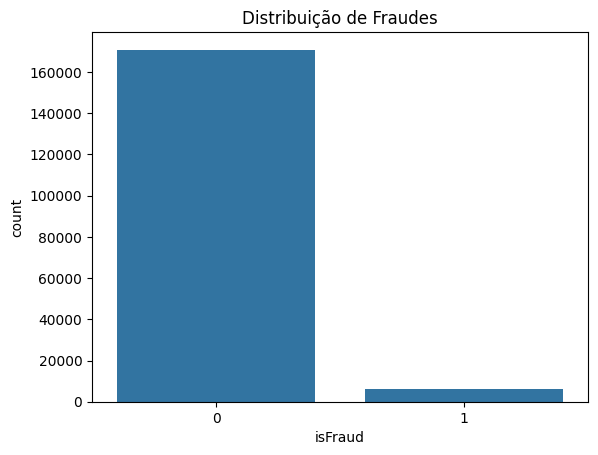

ValueError: could not convert string to float: 'W'

In [ ]:
fraud_detection = FraudDetection('/content/drive/MyDrive/Modulo 11/train_transaction.csv')
fraud_detection.run_all()